# 5. Machine learning fundamentals: the learning problem, generalisation and evaluation

Everything in this course rests on one question: **how can a program that has only seen a
finite sample of data make good predictions about data it has never seen?** This notebook
develops the vocabulary and the mental model needed to answer it. We formalise what a
"learning problem" is, meet the three fundamental families of tasks, see why fitting the
training data well is *not* the goal, derive the bias–variance decomposition, and learn the
evaluation protocols — hold-out sets, cross-validation, learning curves — that every later
notebook relies on.

The methods used here (polynomial regression, nearest neighbours, logistic regression) are
treated as black boxes; each gets its own notebook later. What matters now is the
*methodology* that surrounds any model.

**Prerequisites:** notebooks 1 (NumPy/pandas) and 2 (mathematics essentials). Notebook 4
(preprocessing) is helpful but not required.

## Learning objectives

After working through this notebook you will be able to

- state the supervised learning problem formally (data, hypothesis space, loss, risk) and explain *empirical risk minimisation*;
- distinguish supervised, unsupervised and reinforcement learning, and regression from classification;
- explain underfitting and overfitting, and diagnose them with training/validation curves;
- derive the bias–variance decomposition of the expected squared error and reproduce it in a simulation;
- use train/validation/test splits and $k$-fold cross-validation correctly, including stratification and repeated CV;
- read learning curves and validation curves to decide whether to collect more data, use a bigger model, or regularise;
- use the scikit-learn estimator API (`fit`, `predict`, `transform`, `score`) and sensible baselines;
- recognise data leakage and the "no free lunch" theorem as the two most important caveats in practice.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from course_utils import set_style, PALETTE, plot_decision_boundary

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
set_style()

## 1. What is machine learning?

Tom Mitchell's often-quoted definition (Mitchell, 1997) is operational rather than
philosophical:

> A computer program is said to **learn** from experience $E$ with respect to some class of
> tasks $T$ and performance measure $P$, if its performance at tasks in $T$, as measured by
> $P$, improves with experience $E$.

Three ingredients, then: a *task* (predict house prices, recognise spoken words), a
*performance measure* (mean squared error, accuracy, revenue), and *experience* (data).
Machine learning is the discipline of building programs whose behaviour is determined by
data rather than by hand-written rules. That is a good idea exactly when the rules are hard
to write down explicitly — nobody can write the `if` statements that recognise a cat in a
photo — but examples are plentiful.

### 1.1 The three families of learning problems

| Family | What the data look like | Goal | Examples |
|---|---|---|---|
| **Supervised learning** | pairs $(\mathbf{x}_i, y_i)$ of inputs and targets | learn a function $f$ with $f(\mathbf{x}) \approx y$ on *new* inputs | spam filtering, price prediction, medical diagnosis |
| **Unsupervised learning** | inputs $\mathbf{x}_i$ only | find structure: clusters, low-dimensional representations, densities, anomalies | customer segmentation, topic discovery, compression |
| **Reinforcement learning** | an *agent* acts in an environment and receives rewards | learn a policy that maximises long-run reward | game playing, robotics, recommendation with feedback loops |

Between these sit *semi-supervised* learning (a few labels, many unlabelled points) and
*self-supervised* learning (labels manufactured from the data itself, as in modern language
models). This course concentrates on supervised learning (notebooks 5–12 and 15–16) and unsupervised learning (notebooks 13–14); reinforcement learning is only sketched in the
outlook.

Within supervised learning, the type of the target decides the task:

- **Regression** — $y \in \mathbb{R}$ (or $\mathbb{R}^k$): predict a quantity.
- **Classification** — $y \in \{1, \dots, K\}$: predict a category. $K=2$ is *binary*,
  $K>2$ *multi-class*; when several labels can be true at once it is *multi-label*.

Many other problems (ranking, structured prediction, forecasting) are reductions to these
two.

### 1.2 The supervised learning problem, formally

Let us fix notation that will be used throughout the course (see also the notation table in
notebook 0):

- An input (feature vector) $\mathbf{x} \in \mathcal{X} \subseteq \mathbb{R}^d$ and a target $y \in \mathcal{Y}$.
- A training set $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$, which we assume to be drawn
  **independently and identically distributed (i.i.d.)** from an unknown joint distribution
  $P(\mathbf{x}, y)$.
- A **hypothesis space** $\mathcal{H}$: the set of functions our learning algorithm can
  produce (all linear functions, all decision trees of depth $\le 5$, all neural networks
  of a given architecture, …).
- A **loss function** $\ell(y, \hat{y}) \ge 0$ that measures how bad the prediction
  $\hat{y} = f(\mathbf{x})$ is when the truth is $y$: squared error $(y - \hat{y})^2$ for
  regression, the 0–1 loss $\mathbb{1}[y \ne \hat{y}]$ for classification, and many others.

What we actually care about is the **risk** (expected loss, generalisation error) of a
hypothesis $f$:

$$
R(f) \;=\; \mathbb{E}_{(\mathbf{x}, y) \sim P}\big[\ell(y, f(\mathbf{x}))\big].
$$

The best possible predictor $f^\star = \arg\min_f R(f)$ over *all* functions is called the
**Bayes predictor**, and its risk $R(f^\star)$ the **Bayes error** — the irreducible error
caused by noise in $y$ that no model can remove. For squared error the Bayes predictor is
the conditional mean $f^\star(\mathbf{x}) = \mathbb{E}[y \mid \mathbf{x}]$; for the 0–1 loss
it is the most probable class $\arg\max_k P(y = k \mid \mathbf{x})$.

We cannot compute $R(f)$ because $P$ is unknown. What we *can* compute is the
**empirical risk** on the training data,

$$
\hat{R}_n(f) \;=\; \frac{1}{n} \sum_{i=1}^n \ell\big(y_i, f(\mathbf{x}_i)\big),
$$

and the most important learning principle in this course is simply

$$
\hat{f} \;=\; \arg\min_{f \in \mathcal{H}} \hat{R}_n(f) \qquad \text{(empirical risk minimisation, ERM).}
$$

> **Key idea.** Learning = choosing a hypothesis space $\mathcal{H}$ and picking the member of
> $\mathcal{H}$ that fits the training data best. Almost every algorithm in this course is ERM
> for some $\mathcal{H}$ and some loss, often with an added *regularisation* term that
> discourages complex hypotheses (notebook 6).

The catch, and the reason this notebook exists: $\hat{R}_n(\hat{f})$ is an **optimistically
biased** estimate of $R(\hat{f})$, because $\hat{f}$ was chosen to make $\hat{R}_n$ small.
The larger and more flexible $\mathcal{H}$, the larger the gap can be. Statistical learning
theory (Vapnik, 1995; Shalev-Shwartz & Ben-David, 2014) makes this precise with bounds of
the form

$$
R(\hat{f}) \;\le\; \hat{R}_n(\hat{f}) \;+\; \underbrace{\text{complexity}(\mathcal{H}, n, \delta)}_{\text{shrinks with } n,\ \text{grows with } |\mathcal{H}|}
\qquad \text{with probability } \ge 1-\delta .
$$

We will not use such bounds numerically — they are far too loose in practice — but they
carry the right message: *generalisation improves with more data and with a hypothesis
space that is no richer than necessary.*

### 1.3 Seeing $P$, the risk and the empirical risk

Those three objects are easy to write down and hard to picture, so let us draw them in a
world where we know everything. Take $x$ uniform on $[-3, 3]$ and $y = 1 + 0.8\,x +
\varepsilon$ with $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, $\sigma = 1$. The joint
distribution $P(\mathbf{x}, y)$ is then the cloud in the left panel below; the Bayes
predictor is the straight line $f^\star(x) = 1 + 0.8x$ and the Bayes risk is $\sigma^2 = 1$.
A *training set* is one i.i.d. draw of $n$ points from that cloud — the middle panel shows
three of them, and they are visibly different objects. The right panel draws the
consequence: the empirical risk of one **fixed** predictor, recomputed on 2 000 independent
training sets of $n = 25$, is itself a random quantity scattered around the risk.

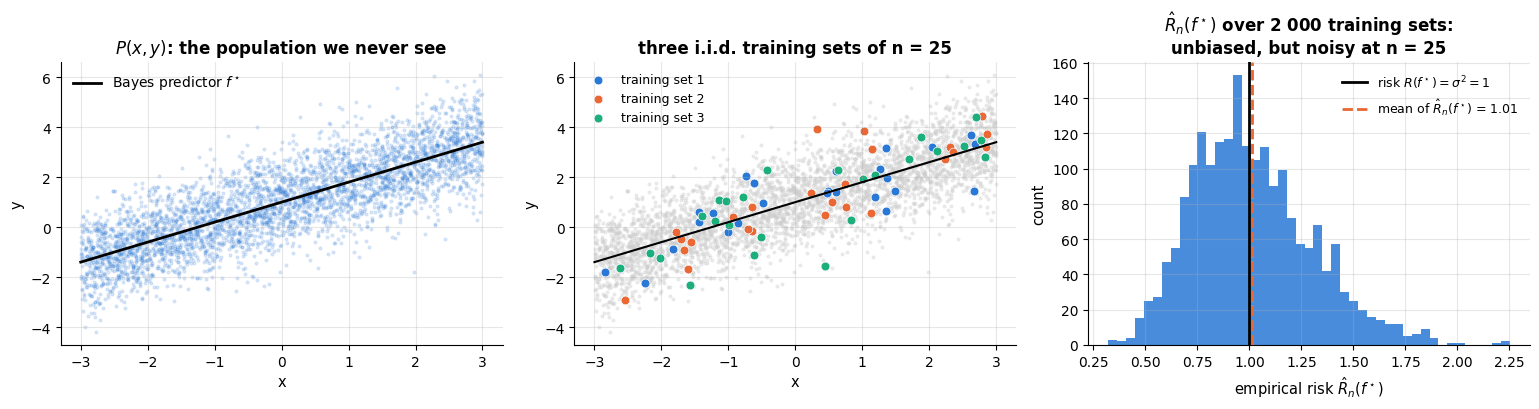

risk of the Bayes predictor = 1.00;  empirical risk over 2000 draws: mean 1.01, sd 0.29, range [0.32, 2.25]


In [2]:
def sample_population(n, rng=rng):
    """One i.i.d. draw of n points from P(x, y):  y = 1 + 0.8 x + N(0, 1)."""
    x = rng.uniform(-3, 3, n)
    return x, 1.0 + 0.8 * x + rng.normal(0, 1.0, n)

def bayes_predictor(x):
    return 1.0 + 0.8 * x

x_pop, y_pop = sample_population(4000)          # a stand-in for the (infinite) population
n_small = 25
draws = [sample_population(n_small) for _ in range(3)]

emp_risk = np.empty(2000)                        # empirical risk of f* on 2000 fresh training sets
for i in range(2000):
    xs, ys = sample_population(n_small)
    emp_risk[i] = np.mean((ys - bayes_predictor(xs)) ** 2)

grid = np.linspace(-3, 3, 100)
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))
axes[0].scatter(x_pop, y_pop, s=4, color=PALETTE[0], alpha=0.15)
axes[0].plot(grid, bayes_predictor(grid), color="black", lw=2, label="Bayes predictor $f^\\star$")
axes[0].set_title("$P(x, y)$: the population we never see")
axes[0].legend(loc="upper left")

axes[1].scatter(x_pop, y_pop, s=4, color="0.8", alpha=0.3)
for j, (xs, ys) in enumerate(draws):
    axes[1].scatter(xs, ys, s=40, color=PALETTE[j], edgecolor="white", lw=0.5, label=f"training set {j + 1}")
axes[1].plot(grid, bayes_predictor(grid), color="black", lw=1.5)
axes[1].set_title(f"three i.i.d. training sets of n = {n_small}")
axes[1].legend(loc="upper left", fontsize=9)

axes[2].hist(emp_risk, bins=45, color=PALETTE[0], alpha=0.85)
axes[2].axvline(1.0, color="black", lw=2, label="risk $R(f^\\star) = \\sigma^2 = 1$")
axes[2].axvline(emp_risk.mean(), color=PALETTE[1], ls="--", lw=2,
                label=f"mean of $\\hat{{R}}_n(f^\\star)$ = {emp_risk.mean():.2f}")
axes[2].set_title("$\\hat{R}_n(f^\\star)$ over 2 000 training sets:\nunbiased, but noisy at n = 25")
axes[2].set_xlabel("empirical risk $\\hat{R}_n(f^\\star)$")
axes[2].set_ylabel("count")
axes[2].legend(fontsize=9)
for ax in axes[:2]:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()
print(f"risk of the Bayes predictor = 1.00;  empirical risk over 2000 draws: "
      f"mean {emp_risk.mean():.2f}, sd {emp_risk.std():.2f}, range [{emp_risk.min():.2f}, {emp_risk.max():.2f}]")

Empirical risk is an *unbiased* estimate of risk for a predictor chosen **before** seeing the
data — the histogram is centred on 1 — but a noisy one. ERM, however, does not use a
predictor chosen in advance: it picks the minimiser of that noisy quantity. The next figure
shows what that does. For a two-parameter hypothesis space $f(x) = w_0 + w_1 x$ we can draw
the whole objective as a surface over $(w_0, w_1)$: the risk $R$ on the left (computed on the
population), and the empirical risk $\hat{R}_n$ of two different training sets of $n = 25$
beside it. ERM returns the star; the truth is the black cross.

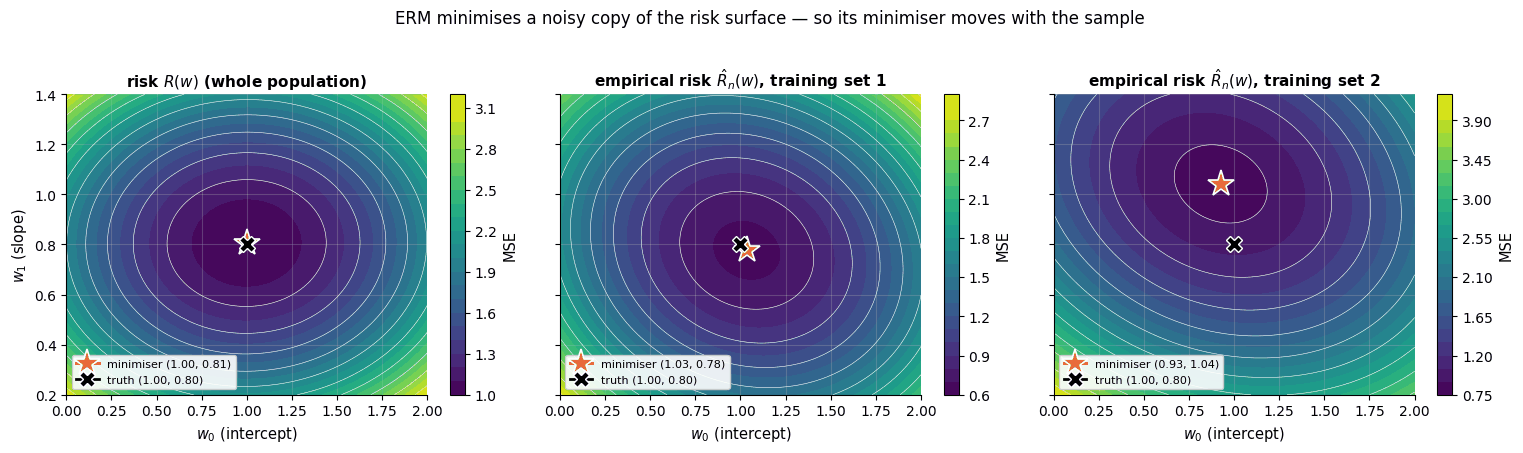

In [3]:
def mse_surface(x, y, W0, W1):
    """Mean squared error of f(x) = w0 + w1 x on a grid of (w0, w1), in closed form."""
    my, mx, mxy, mx2, my2 = y.mean(), x.mean(), (x * y).mean(), (x ** 2).mean(), (y ** 2).mean()
    return my2 - 2 * W0 * my - 2 * W1 * mxy + W0 ** 2 + 2 * W0 * W1 * mx + W1 ** 2 * mx2

W0, W1 = np.meshgrid(np.linspace(0.0, 2.0, 200), np.linspace(0.2, 1.4, 200))
panels = [("risk $R(w)$ (whole population)", x_pop, y_pop)] + \
         [(f"empirical risk $\\hat{{R}}_n(w)$, training set {j + 1}", *draws[j]) for j in range(2)]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), sharex=True, sharey=True)
for ax, (title, xs, ys) in zip(axes, panels):
    Z = mse_surface(xs, ys, W0, W1)
    cs = ax.contourf(W0, W1, Z, levels=25, cmap="viridis")
    ax.contour(W0, W1, Z, levels=12, colors="white", linewidths=0.4)
    w_hat = np.linalg.lstsq(np.column_stack([np.ones(len(xs)), xs]), ys, rcond=None)[0]
    ax.plot(*w_hat, marker="*", ms=20, color=PALETTE[1], mec="white", mew=1.2,
            label=f"minimiser ({w_hat[0]:.2f}, {w_hat[1]:.2f})")
    ax.plot(1.0, 0.8, marker="X", ms=11, color="black", mec="white", mew=1.0, label="truth (1.00, 0.80)")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("$w_0$ (intercept)")
    ax.legend(loc="lower left", fontsize=8, frameon=True, facecolor="white", framealpha=0.9)
    fig.colorbar(cs, ax=ax, label="MSE")
axes[0].set_ylabel("$w_1$ (slope)")
fig.suptitle("ERM minimises a noisy copy of the risk surface — so its minimiser moves with the sample", y=1.02)
plt.tight_layout()
plt.show()

The three bowls have the same shape but different bottoms. Minimising the empirical bowl is
the best we can do, and it is a good idea — the minimisers are close to the truth — but the
value at the minimum is *lower* than the risk there, and the location wanders from sample to
sample. Those two facts are exactly the optimism and the variance that the rest of this
notebook is about.

## 2. A first look at underfitting and overfitting

Let us make the abstract concrete with a one-dimensional regression problem where we know
the truth. We generate data from

$$
y = \sin(2\pi x) + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.3,
$$

with $x$ uniform on $[0, 1]$. The Bayes predictor is $\sin(2\pi x)$ and the Bayes error
(for squared loss) is $\sigma^2 = 0.09$.

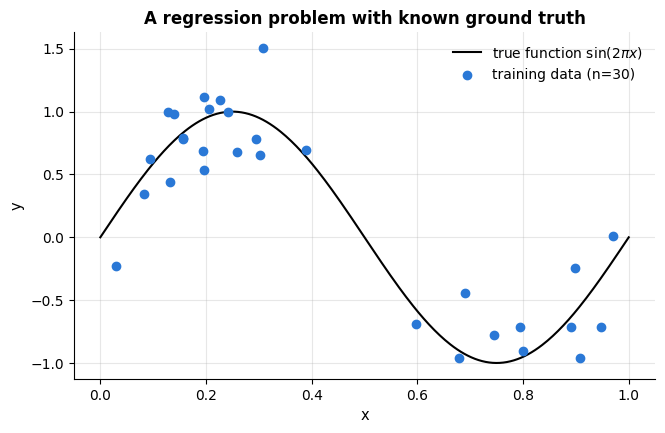

In [4]:
def true_function(x):
    return np.sin(2 * np.pi * x)

def make_sine_data(n, noise=0.3, rng=rng):
    x = rng.uniform(0, 1, n)
    y = true_function(x) + rng.normal(0, noise, n)
    return x, y

x_train, y_train = make_sine_data(30)
x_test, y_test = make_sine_data(1000)   # a large test set approximates the true risk well

x_grid = np.linspace(0, 1, 300)
fig, ax = plt.subplots()
ax.plot(x_grid, true_function(x_grid), color="black", lw=1.5, label="true function $\\sin(2\\pi x)$")
ax.scatter(x_train, y_train, color=PALETTE[0], label=f"training data (n={len(x_train)})", zorder=3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("A regression problem with known ground truth")
ax.legend()
plt.show()

Our hypothesis spaces will be **polynomials of degree $p$**,
$f(x) = w_0 + w_1 x + w_2 x^2 + \dots + w_p x^p$, fitted by least squares. Degree $p$ is a
*hyper-parameter*: it is not learned from the data by the fitting procedure but chosen by us
— and it controls the size of $\mathcal{H}$. We build the model as a scikit-learn
**pipeline** (feature expansion followed by a linear model); pipelines are explained in
detail in notebook 4 and are used everywhere from here on.

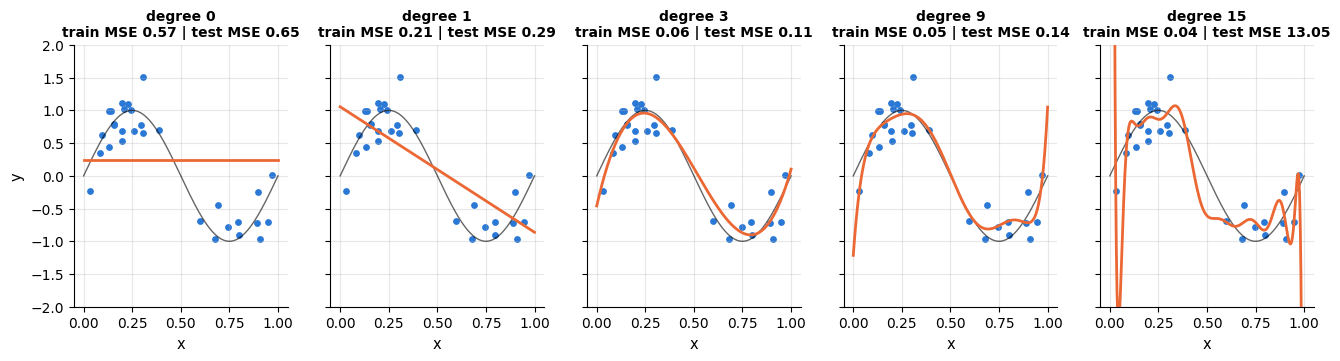

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def poly_model(degree):
    return make_pipeline(PolynomialFeatures(degree), LinearRegression())

degrees = [0, 1, 3, 9, 15]
fig, axes = plt.subplots(1, len(degrees), figsize=(16, 3.4), sharey=True)
for ax, p in zip(axes, degrees):
    model = poly_model(p).fit(x_train[:, None], y_train)
    mse_train = mean_squared_error(y_train, model.predict(x_train[:, None]))
    mse_test = mean_squared_error(y_test, model.predict(x_test[:, None]))
    ax.plot(x_grid, true_function(x_grid), color="black", lw=1, alpha=0.6)
    ax.scatter(x_train, y_train, s=15, color=PALETTE[0])
    ax.plot(x_grid, model.predict(x_grid[:, None]), color=PALETTE[1], lw=2)
    ax.set_ylim(-2, 2)
    ax.set_title(f"degree {p}\ntrain MSE {mse_train:.2f} | test MSE {mse_test:.2f}", fontsize=10)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.show()

Three regimes are visible:

- **Underfitting** (degree 0–1): the hypothesis space is too small to represent the truth.
  Training *and* test error are high. More data would not help — the model has high
  **bias**.
- **A good fit** (degree 3): captures the shape; test error close to the Bayes error 0.09.
- **Overfitting** (degree 9–15): the polynomial wiggles through the noise. Training error
  keeps falling, but test error explodes. The model has high **variance**: a different
  sample of 30 points would give a completely different curve.

The standard picture summarises this as a U-shaped test error against model complexity.
Let us draw it — and, because a single training set is noisy, average over several
training sets.

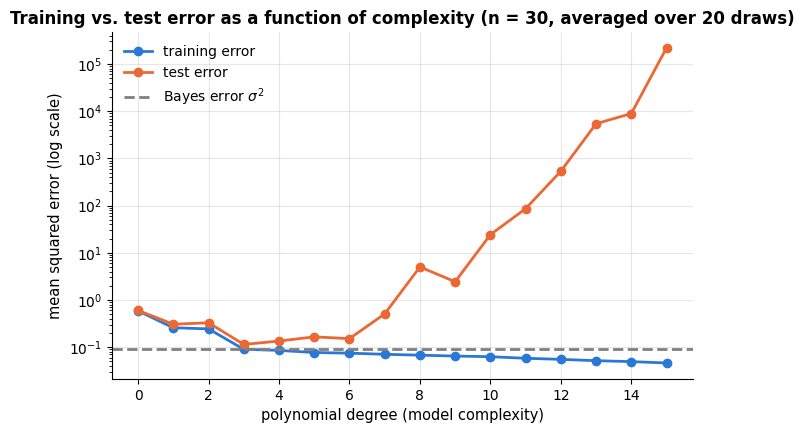

Lowest average test error at degree 3: 0.114


In [6]:
degrees = np.arange(0, 16)
n_repeats = 20
train_err = np.zeros((n_repeats, len(degrees)))
test_err = np.zeros((n_repeats, len(degrees)))

for r in range(n_repeats):
    xtr, ytr = make_sine_data(30)
    for j, p in enumerate(degrees):
        model = poly_model(p).fit(xtr[:, None], ytr)
        train_err[r, j] = mean_squared_error(ytr, model.predict(xtr[:, None]))
        test_err[r, j] = mean_squared_error(y_test, model.predict(x_test[:, None]))

fig, ax = plt.subplots()
ax.plot(degrees, train_err.mean(0), marker="o", label="training error")
ax.plot(degrees, test_err.mean(0), marker="o", label="test error")
ax.axhline(0.09, color="gray", ls="--", label="Bayes error $\\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree (model complexity)")
ax.set_ylabel("mean squared error (log scale)")
ax.set_title("Training vs. test error as a function of complexity (n = 30, averaged over 20 draws)")
ax.legend()
plt.show()
best = degrees[test_err.mean(0).argmin()]
print(f"Lowest average test error at degree {best}: {test_err.mean(0).min():.3f}")

> **Key idea.** Training error is not a measure of quality; it decreases monotonically with
> complexity. Only error on data that the model has *not* seen tells us how well it
> generalises. Every evaluation protocol in this notebook is a way of obtaining an honest
> estimate of that quantity.

> **Going deeper — double descent.** The U-shape is the classical story, and it holds for
> the models in this notebook. For very over-parameterised models (huge neural networks,
> or polynomials with degree ≫ $n$ fitted with minimum-norm least squares) the test error
> can *decrease again* beyond the interpolation threshold — the "double descent" phenomenon
> (Belkin et al., 2019; Nakkiran et al., 2020). It does not contradict anything here, but it
> shows that "complexity" is subtler than the number of parameters.

## 3. The bias–variance decomposition

Why exactly does test error behave this way? For squared loss there is an exact answer.
Fix a test input $\mathbf{x}$ and let $y = f^\star(\mathbf{x}) + \varepsilon$ with
$\mathbb{E}[\varepsilon] = 0$, $\operatorname{Var}[\varepsilon] = \sigma^2$. Our learning
algorithm, applied to a random training set $\mathcal{D}$, produces a prediction
$\hat{f}_\mathcal{D}(\mathbf{x})$ — a random variable, because $\mathcal{D}$ is random.
Write $\bar{f}(\mathbf{x}) = \mathbb{E}_\mathcal{D}[\hat{f}_\mathcal{D}(\mathbf{x})]$ for
the *average* prediction over training sets. Then the expected squared error at
$\mathbf{x}$ decomposes as

$$
\mathbb{E}_{\mathcal{D}, \varepsilon}\Big[\big(y - \hat{f}_\mathcal{D}(\mathbf{x})\big)^2\Big]
\;=\;
\underbrace{\big(f^\star(\mathbf{x}) - \bar{f}(\mathbf{x})\big)^2}_{\text{bias}^2}
\;+\;
\underbrace{\mathbb{E}_\mathcal{D}\Big[\big(\hat{f}_\mathcal{D}(\mathbf{x}) - \bar{f}(\mathbf{x})\big)^2\Big]}_{\text{variance}}
\;+\;
\underbrace{\sigma^2}_{\text{noise}} .
$$

**Derivation.** Add and subtract $\bar f(\mathbf{x})$ inside the square, expand
$\big((f^\star - \bar f) + (\bar f - \hat f_\mathcal{D}) + \varepsilon\big)^2$, and take
expectations. All three cross terms vanish: $\mathbb{E}[\varepsilon] = 0$ and $\varepsilon$
is independent of $\mathcal{D}$, and $\mathbb{E}_\mathcal{D}[\bar f - \hat f_\mathcal{D}] = 0$
by definition of $\bar f$. (Geman, Bienenstock & Doursat, 1992, is the classic reference;
Hastie, Tibshirani & Friedman, 2009, §7.3 gives the textbook treatment.)

Interpretation:

- **Bias** measures how far the *average* model is from the truth — the systematic error
  caused by a hypothesis space that cannot represent $f^\star$ (degree-1 polynomials for a
  sine wave).
- **Variance** measures how much the fitted model fluctuates from one training set to
  another — sensitivity to the particular noise in the sample (degree-15 polynomials).
- **Noise** is the Bayes error; no algorithm can go below it.

Simple models: high bias, low variance. Flexible models: low bias, high variance. The
optimal complexity balances the two — the *bias–variance trade-off*. Increasing $n$ reduces
variance (the fit is anchored by more points) but leaves bias unchanged, which is exactly
why a bigger dataset lets us afford a more flexible model.

Let us verify the decomposition numerically: draw many training sets, fit polynomials of
each degree, and measure bias and variance on a grid of test points.

In [7]:
x_eval = np.linspace(0.05, 0.95, 50)          # evaluation points
n_sets, n_train, sigma = 200, 30, 0.3
degrees = [1, 2, 3, 4, 5, 6, 7, 8]
rows = []
for p in degrees:
    preds = np.zeros((n_sets, len(x_eval)))
    for s in range(n_sets):
        xtr, ytr = make_sine_data(n_train, noise=sigma)
        preds[s] = poly_model(p).fit(xtr[:, None], ytr).predict(x_eval[:, None])
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - true_function(x_eval)) ** 2)
    var = np.mean(preds.var(axis=0))
    rows.append({"degree": p, "bias^2": bias2, "variance": var, "noise": sigma**2,
                 "bias^2+var+noise": bias2 + var + sigma**2})
bv = pd.DataFrame(rows).set_index("degree")
bv.round(3)

,bias^2,variance,noise,bias^2+var+noise
degree,,,,
1,0.155,0.023,0.09,0.268
2,0.147,0.047,0.09,0.284
3,0.003,0.014,0.09,0.107
4,0.002,0.021,0.09,0.114
5,0.000,0.026,0.09,0.116
6,0.000,0.088,0.09,0.179
7,0.001,0.082,0.09,0.172
8,0.000,0.121,0.09,0.211


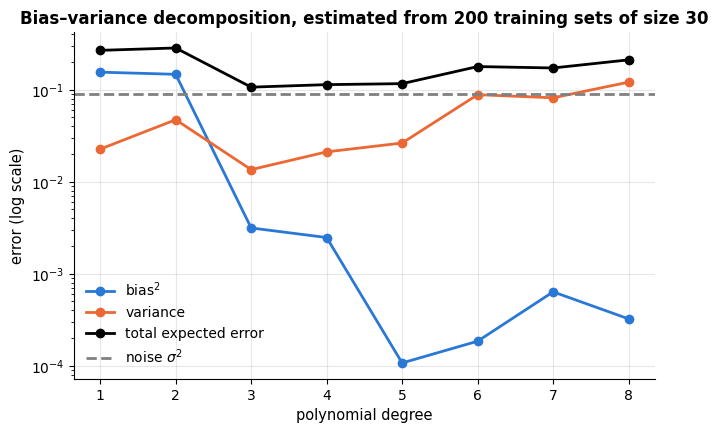

In [8]:
fig, ax = plt.subplots()
ax.plot(bv.index, bv["bias^2"], marker="o", label="bias$^2$")
ax.plot(bv.index, bv["variance"], marker="o", label="variance")
ax.plot(bv.index, bv["bias^2+var+noise"], marker="o", color="black", label="total expected error")
ax.axhline(sigma**2, color="gray", ls="--", label="noise $\\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("error (log scale)")
ax.set_title("Bias–variance decomposition, estimated from 200 training sets of size 30")
ax.legend()
plt.show()

Let us also *see* variance: the spread of fitted curves across training sets.

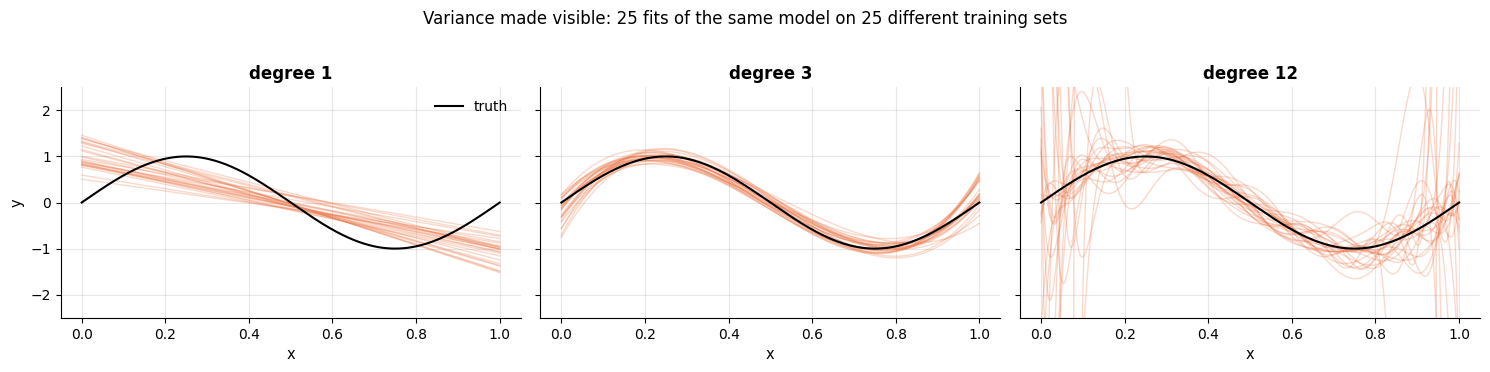

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, p in zip(axes, [1, 3, 12]):
    for s in range(25):
        xtr, ytr = make_sine_data(n_train, noise=sigma)
        ax.plot(x_grid, poly_model(p).fit(xtr[:, None], ytr).predict(x_grid[:, None]),
                color=PALETTE[1], alpha=0.25, lw=1)
    ax.plot(x_grid, true_function(x_grid), color="black", lw=1.5, label="truth")
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(f"degree {p}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
fig.suptitle("Variance made visible: 25 fits of the same model on 25 different training sets", y=1.02)
plt.tight_layout()
plt.show()

The degree-1 fits all look alike but are all wrong (bias); the degree-12 fits are, on
average, close to the truth but scatter wildly (variance). (Beyond degree 8 the variance
of unregularised polynomial fits on 30 points explodes by orders of magnitude, which is
why the table stops there; regularisation, notebook 6, is the cure.)

> **Why it matters.** Nearly every design decision in machine learning is a bias–variance
> decision: regularisation strength, tree depth, the number of neighbours $k$, the number of
> boosting rounds, network size, dropout, early stopping, and ensembling all move a model
> along this trade-off. When a model performs poorly, the first diagnostic question is
> always: *is the problem bias (underfitting) or variance (overfitting)?* — because the
> remedies are opposite (bigger model / more features vs. more data / regularisation /
> simpler model).

## 4. Evaluation protocols: hold-out sets and cross-validation

The polynomial example used a large synthetic test set. In practice we have one finite
dataset and must carve an honest estimate of generalisation error out of it.

### 4.1 Train / validation / test

The basic protocol splits the data into three disjoint parts:

1. **Training set** — used to fit the model parameters (ERM).
2. **Validation set** (development set) — used to *choose* between models and
   hyper-parameters (polynomial degree, $k$, regularisation strength …).
3. **Test set** — touched *once*, at the very end, to report the final performance.

Why three and not two? Because choosing hyper-parameters by looking at an error estimate is
itself a form of fitting: if we try 100 configurations and keep the one with the best
validation score, that score is optimistically biased in exactly the same way as training
error (Cawley & Talbot, 2010). The untouched test set protects us from fooling ourselves.

This is worth a picture, because the whole discipline of honest evaluation is contained in
it: every row of the data set belongs to exactly one part, and each part answers exactly one
question.

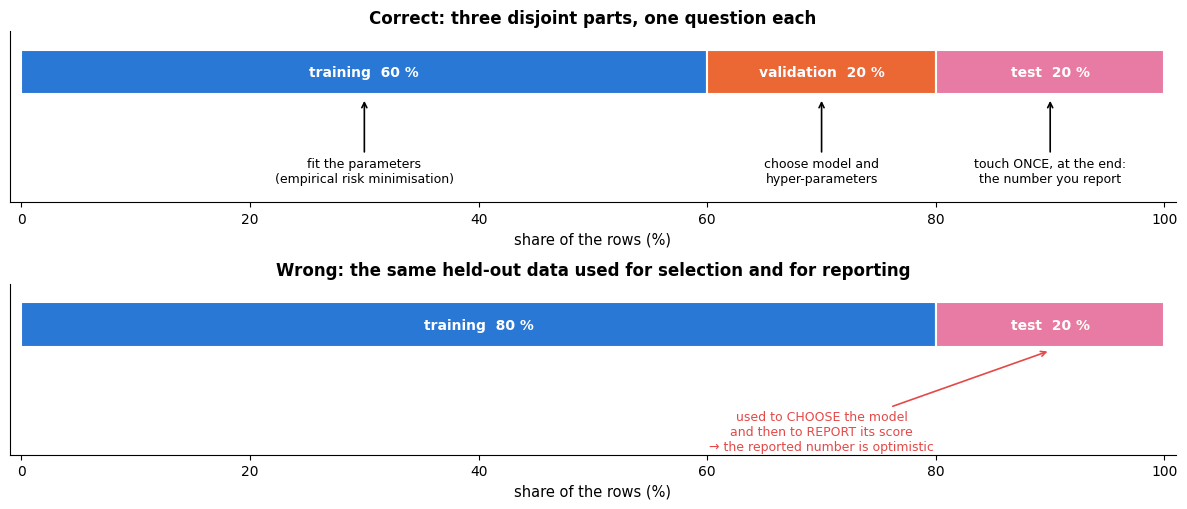

In [10]:
def draw_blocks(ax, spans, y=0, height=0.55, fontsize=10):
    """Draw a horizontal row of labelled coloured blocks: spans = [(label, start, width, colour), ...]."""
    for label, start, width, colour in spans:
        ax.barh(y, width, left=start, height=height, color=colour, edgecolor="white", lw=1.5)
        ax.text(start + width / 2, y, label, ha="center", va="center", color="white",
                fontweight="bold", fontsize=fontsize)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.2))
draw_blocks(axes[0], [("training  60 %", 0, 60, PALETTE[0]),
                      ("validation  20 %", 60, 20, PALETTE[1]),
                      ("test  20 %", 80, 20, PALETTE[4])])
for text, xpos in [("fit the parameters\n(empirical risk minimisation)", 30),
                   ("choose model and\nhyper-parameters", 70),
                   ("touch ONCE, at the end:\nthe number you report", 90)]:
    axes[0].annotate(text, xy=(xpos, -0.32), xytext=(xpos, -1.05), ha="center", va="top", fontsize=9,
                     arrowprops={"arrowstyle": "->", "lw": 1.2})
axes[0].set_title("Correct: three disjoint parts, one question each")

draw_blocks(axes[1], [("training  80 %", 0, 80, PALETTE[0]), ("test  20 %", 80, 20, PALETTE[4])])
axes[1].annotate("used to CHOOSE the model\nand then to REPORT its score\n→ the reported number is optimistic",
                 xy=(90, -0.32), xytext=(70, -1.05), ha="center", va="top", fontsize=9, color=PALETTE[7],
                 arrowprops={"arrowstyle": "->", "lw": 1.2, "color": PALETTE[7]})
axes[1].set_title("Wrong: the same held-out data used for selection and for reporting")

for ax in axes:
    ax.set_xlim(-1, 101)
    ax.set_ylim(-1.6, 0.5)
    ax.set_yticks([])
    ax.set_xlabel("share of the rows (%)")
    ax.grid(False)
plt.tight_layout()
plt.show()

Typical proportions are 60/20/20 or 80/10/10 for medium-sized data; with millions of rows
the validation and test sets can be a much smaller fraction. For **classification**, split
*stratified* so that each part has the same class proportions (`stratify=y`); for
**time-ordered** data, split by time (notebook 16); for **grouped** data (several rows per
patient/customer/session) split by group (`GroupKFold`) so that no group appears on both
sides.

We use the breast cancer Wisconsin data (Street, Wolberg & Mangasarian, 1993; 569 tumours,
30 features computed from cell-nucleus images, binary target malignant/benign), bundled with
scikit-learn.

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target          # target: 0 = malignant, 1 = benign
print(f"{X.shape[0]} samples, {X.shape[1]} features; class balance: {y.mean():.1%} benign")

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)  # 0.25 x 0.8 = 0.2
for name, part in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(f"{name:11s} n = {len(part):3d}   benign fraction = {part.mean():.3f}")

569 samples, 30 features; class balance: 62.7% benign
train       n = 341   benign fraction = 0.628
validation  n = 114   benign fraction = 0.623
test        n = 114   benign fraction = 0.632


### 4.2 The scikit-learn estimator API

scikit-learn (Pedregosa et al., 2011; Buitinck et al., 2013) has a small, uniform interface
that makes swapping models trivial:

| Method | Meaning | Who has it |
|---|---|---|
| `est.fit(X, y)` | learn parameters from data; returns `est` | every estimator |
| `est.predict(X)` | predictions (labels or values) | predictors |
| `est.predict_proba(X)` | class probabilities, shape `(n, K)` | probabilistic classifiers |
| `est.decision_function(X)` | raw scores (e.g. signed distance to the boundary) | many classifiers |
| `est.transform(X)` | transformed features | transformers (scalers, encoders, PCA …) |
| `est.fit_transform(X)` | `fit` then `transform`, sometimes faster | transformers |
| `est.score(X, y)` | default metric ($R^2$ for regressors, accuracy for classifiers) | predictors |
| `est.get_params()` / `set_params(...)` | hyper-parameters | every estimator |

Learned quantities end in an underscore (`coef_`, `feature_importances_`, `classes_`),
hyper-parameters are constructor arguments. Let us use $k$-nearest-neighbours as our
black-box model. (Notebook 8 explains it; for now: a point is classified by a majority
vote among its $k$ closest training points.) Because kNN uses Euclidean distances, features
must be on comparable scales, so we standardise them first — inside a pipeline, so that the
scaler is fitted on training data only.

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

knn = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
knn.fit(X_train, y_train)
print(f"train accuracy      {knn.score(X_train, y_train):.3f}")
print(f"validation accuracy {knn.score(X_val, y_val):.3f}")
print("first five predicted probabilities (malignant, benign):")
print(knn.predict_proba(X_val.iloc[:5]).round(2))

train accuracy      0.974
validation accuracy 0.956
first five predicted probabilities (malignant, benign):
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]


Now the hyper-parameter search that motivated the validation set: which $k$?

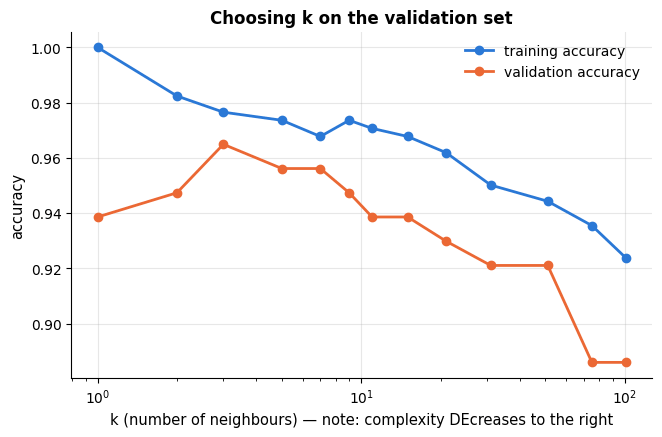

best k on validation: 3  (validation accuracy 0.965)


In [13]:
ks = [1, 2, 3, 5, 7, 9, 11, 15, 21, 31, 51, 75, 101]
scores = pd.DataFrame(index=ks, columns=["train", "validation"], dtype=float)
for k in ks:
    model = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))]).fit(X_train, y_train)
    scores.loc[k] = [model.score(X_train, y_train), model.score(X_val, y_val)]

fig, ax = plt.subplots()
ax.plot(scores.index, scores["train"], marker="o", label="training accuracy")
ax.plot(scores.index, scores["validation"], marker="o", label="validation accuracy")
ax.set_xscale("log")
ax.set_xlabel("k (number of neighbours) — note: complexity DEcreases to the right")
ax.set_ylabel("accuracy")
ax.set_title("Choosing k on the validation set")
ax.legend()
plt.show()
best_k = int(scores["validation"].idxmax())
print(f"best k on validation: {best_k}  (validation accuracy {scores.loc[best_k, 'validation']:.3f})")

For $k=1$ the training accuracy is 100 % (every point is its own nearest neighbour) — a
textbook overfit. Very large $k$ underfits: the prediction tends to the majority class.
Notice how *noisy* the validation curve is with only 114 validation points: neighbouring
values of $k$ differ by one or two misclassified samples. This noise is the motivation for
cross-validation.

### 4.3 $k$-fold cross-validation

A single validation split wastes data (the model is trained on less) and gives a noisy
estimate (it depends on which points happened to land in the validation set).
**$k$-fold cross-validation** (Stone, 1974; Kohavi, 1995) fixes both:

1. Split the (training + validation) data into $k$ equal folds.
2. For $j = 1, \dots, k$: train on all folds except fold $j$, evaluate on fold $j$.
3. Report the mean (and standard deviation) of the $k$ scores.

Every sample is used for validation exactly once and for training $k-1$ times. The
estimate has lower variance than a single split, at the cost of $k$ fits. $k = 5$ or $10$
are the usual choices; $k = n$ is *leave-one-out* (LOO), which is nearly unbiased but
expensive and, perhaps surprisingly, has *high* variance because the $n$ training sets are
almost identical (Hastie et al., 2009, §7.10). Use `StratifiedKFold` for classification
(scikit-learn does this automatically when you pass an integer `cv` to a classifier), and
`shuffle=True` unless the data are ordered on purpose.

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
fold_scores = cross_val_score(model, X_trainval, y_trainval, cv=cv, scoring="accuracy")
print("fold accuracies:", fold_scores.round(3))
print(f"mean = {fold_scores.mean():.3f}, std = {fold_scores.std():.3f}")

fold accuracies: [0.967 0.967 0.945 0.956 0.978]
mean = 0.963, std = 0.011


Drawn as blocks, the scheme is immediately clear. Each row is one fit: the orange block is
the fold held out for evaluation, the blue blocks are the folds used for training. (The rows
are ordered by fold so that the held-out block is contiguous; `shuffle=True` means the actual
row indices are scattered.) The right panel shows the five resulting accuracies, their mean
and the standard error of that mean — the number we will quote from now on.

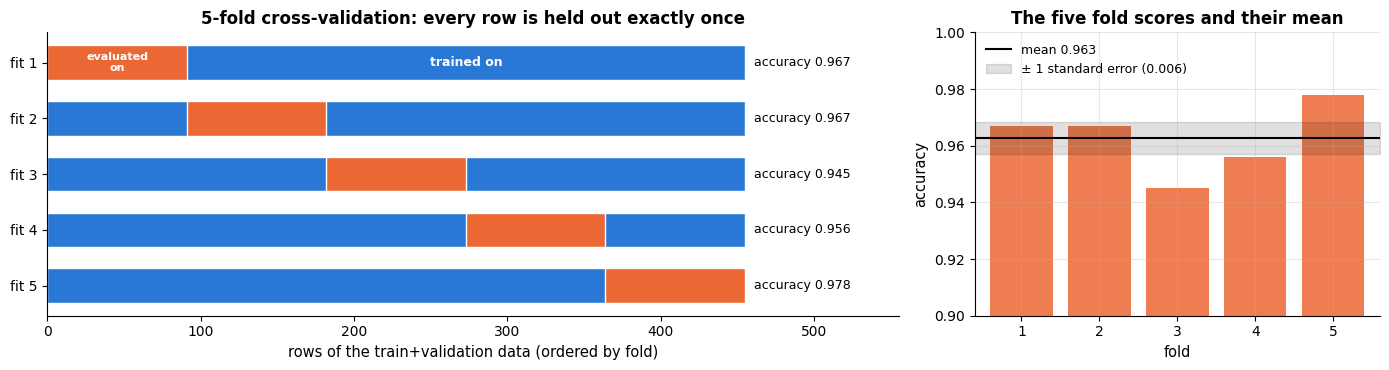

In [15]:
fold_of = np.empty(len(y_trainval), dtype=int)
for f, (_, va) in enumerate(cv.split(X_trainval, y_trainval)):
    fold_of[va] = f
sizes = np.bincount(fold_of)
starts = np.concatenate([[0], np.cumsum(sizes)[:-1]])

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [2.1, 1]})
for f in range(cv.get_n_splits()):
    axes[0].barh(f, len(fold_of), color=PALETTE[0], height=0.62, edgecolor="white")
    axes[0].barh(f, sizes[f], left=starts[f], color=PALETTE[1], height=0.62, edgecolor="white")
    axes[0].text(len(fold_of) + 6, f, f"accuracy {fold_scores[f]:.3f}", va="center", fontsize=9)
axes[0].text(sizes[0] / 2, 0, "evaluated\non", ha="center", va="center", color="white", fontweight="bold", fontsize=8)
axes[0].text((sizes[0] + len(fold_of)) / 2, 0, "trained on", ha="center", va="center",
             color="white", fontweight="bold", fontsize=9)
axes[0].set_yticks(range(cv.get_n_splits()))
axes[0].set_yticklabels([f"fit {f + 1}" for f in range(cv.get_n_splits())])
axes[0].invert_yaxis()
axes[0].set_xlim(0, len(fold_of) * 1.22)
axes[0].set_xlabel("rows of the train+validation data (ordered by fold)")
axes[0].set_title("5-fold cross-validation: every row is held out exactly once")
axes[0].grid(False)

se = fold_scores.std(ddof=1) / np.sqrt(len(fold_scores))
axes[1].bar(np.arange(1, 6), fold_scores, color=PALETTE[1], alpha=0.85)
axes[1].axhline(fold_scores.mean(), color="black", lw=1.5, label=f"mean {fold_scores.mean():.3f}")
axes[1].fill_between([0.4, 5.6], fold_scores.mean() - se, fold_scores.mean() + se,
                     color="black", alpha=0.12, label=f"± 1 standard error ({se:.3f})")
axes[1].set_ylim(0.9, 1.0)
axes[1].set_xlim(0.4, 5.6)
axes[1].set_xticks(np.arange(1, 6))
axes[1].set_xlabel("fold")
axes[1].set_ylabel("accuracy")
axes[1].set_title("The five fold scores and their mean")
axes[1].legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

`cross_validate` returns more: several metrics at once, training scores, fit times and the
fitted estimators.

In [16]:
res = cross_validate(model, X_trainval, y_trainval, cv=cv,
                     scoring=["accuracy", "roc_auc", "f1"], return_train_score=True)
pd.DataFrame(res).round(3)

,fit_time,score_time,test_accuracy,train_accuracy,test_roc_auc,train_roc_auc,test_f1,train_f1
0,0.003,0.009,0.967,0.978,0.980,0.998,0.974,0.983
1,0.003,0.007,0.967,0.973,0.997,0.997,0.974,0.978
2,0.003,0.007,0.945,0.978,0.984,0.998,0.956,0.983
3,0.003,0.007,0.956,0.978,0.981,0.998,0.966,0.983
4,0.003,0.007,0.978,0.975,0.999,0.997,0.982,0.980


Let us redo the choice of $k$ with cross-validation instead of a single validation split
and compare the two curves. We add the *standard error* of the mean as a shaded band: a
difference between two configurations that is smaller than the band is not a real
difference.

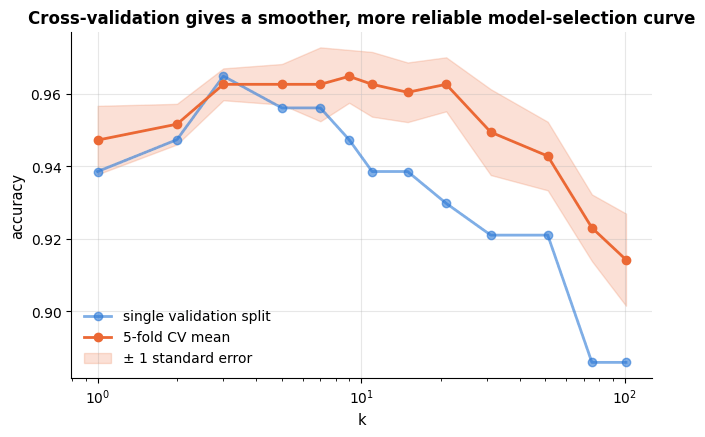

best k by CV: 9   (CV accuracy 0.965 ± 0.007)


In [17]:
cv_mean, cv_se = [], []
for k in ks:
    m = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
    s = cross_val_score(m, X_trainval, y_trainval, cv=cv)
    cv_mean.append(s.mean())
    cv_se.append(s.std(ddof=1) / np.sqrt(len(s)))
cv_mean, cv_se = np.array(cv_mean), np.array(cv_se)

fig, ax = plt.subplots()
ax.plot(ks, scores["validation"], marker="o", alpha=0.6, label="single validation split")
ax.plot(ks, cv_mean, marker="o", label="5-fold CV mean")
ax.fill_between(ks, cv_mean - cv_se, cv_mean + cv_se, alpha=0.2, color=PALETTE[1], label="± 1 standard error")
ax.set_xscale("log")
ax.set_xlabel("k")
ax.set_ylabel("accuracy")
ax.set_title("Cross-validation gives a smoother, more reliable model-selection curve")
ax.legend()
plt.show()
best_k_cv = ks[int(np.argmax(cv_mean))]
print(f"best k by CV: {best_k_cv}   (CV accuracy {cv_mean.max():.3f} ± {cv_se[np.argmax(cv_mean)]:.3f})")

> **Warning — the one-standard-error rule.** When several configurations are within one
> standard error of the best, prefer the *simplest* one (here: the largest $k$, i.e. the
> smoothest model). This heuristic (Breiman et al., 1984) trades a negligible amount of
> estimated accuracy for lower variance and better interpretability.

The rule is easiest to apply by drawing it. Mark the best CV score, drop a horizontal line
one standard error below it, and shade everything above that line: those configurations are
statistically indistinguishable from the winner, so pick the simplest of them.

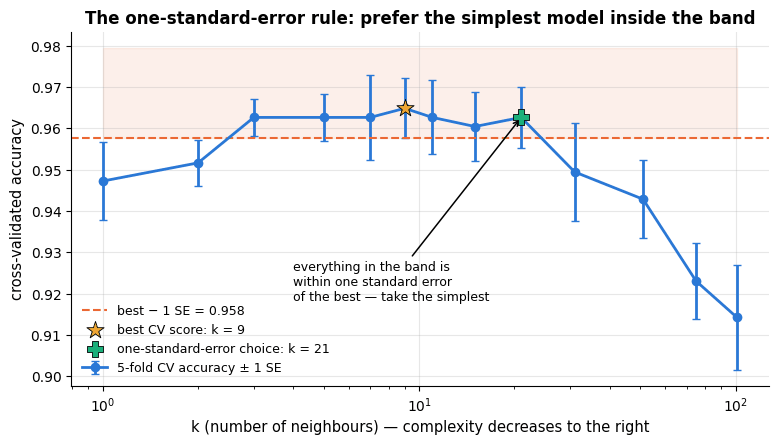

best k = 9 (CV 0.965); one-standard-error choice k = 21 (CV 0.963) — 7 of the 13 values tried are inside the band


In [18]:
best_idx = int(np.argmax(cv_mean))
threshold = cv_mean[best_idx] - cv_se[best_idx]
within = np.flatnonzero(cv_mean >= threshold)
k_1se = ks[within[-1]]                       # largest k = smoothest model that is still within 1 SE

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.errorbar(ks, cv_mean, yerr=cv_se, marker="o", capsize=3, color=PALETTE[0], label="5-fold CV accuracy ± 1 SE")
ax.axhline(threshold, color=PALETTE[1], ls="--", lw=1.5,
           label=f"best − 1 SE = {threshold:.3f}")
ax.fill_between([min(ks), max(ks)], threshold, cv_mean[best_idx] + 2 * cv_se[best_idx],
                color=PALETTE[1], alpha=0.10)
ax.scatter([ks[best_idx]], [cv_mean[best_idx]], s=170, marker="*", color=PALETTE[3], zorder=5,
           edgecolor="black", linewidth=0.6, label=f"best CV score: k = {ks[best_idx]}")
ax.scatter([k_1se], [cv_mean[within[-1]]], s=140, marker="P", color=PALETTE[2], zorder=5,
           edgecolor="black", linewidth=0.6, label=f"one-standard-error choice: k = {k_1se}")
ax.annotate("everything in the band is\nwithin one standard error\nof the best — take the simplest",
            xy=(k_1se, cv_mean[within[-1]]), xytext=(4, cv_mean.min() + 0.004), fontsize=9,
            arrowprops={"arrowstyle": "->", "lw": 1.1})
ax.set_xscale("log")
ax.set_xlabel("k (number of neighbours) — complexity decreases to the right")
ax.set_ylabel("cross-validated accuracy")
ax.set_title("The one-standard-error rule: prefer the simplest model inside the band")
ax.legend(loc="lower left", fontsize=9)
plt.show()
print(f"best k = {ks[best_idx]} (CV {cv_mean[best_idx]:.3f}); one-standard-error choice k = {k_1se} "
      f"(CV {cv_mean[within[-1]]:.3f}) — {len(within)} of the {len(ks)} values tried are inside the band")

### 4.4 Repeated CV, nested CV and the final test score

Even $k$-fold CV depends on the random fold assignment. For small datasets,
`RepeatedStratifiedKFold` (e.g. 5 folds × 5 repetitions) averages that away. And when CV is
used to select hyper-parameters, the selected model's CV score is again optimistic; an
honest estimate requires **nested cross-validation** — an outer loop for evaluation, an
inner loop for selection (Varma & Simon, 2006). Notebook 12 shows nested CV with
`GridSearchCV` inside `cross_val_score`. For now we follow the simplest honest protocol:
select $k$ by CV on the train+validation data, refit on all of it, and evaluate **once** on
the held-out test set.

In [19]:
final_model = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k_cv))])
final_model.fit(X_trainval, y_trainval)
print(f"final kNN (k={best_k_cv}) test accuracy: {final_model.score(X_test, y_test):.3f}")

final kNN (k=9) test accuracy: 0.974


Report this number, and *do not* go back and tune further after seeing it — every
adjustment made in response to the test score leaks information from the test set into
the model and makes the reported number optimistic.

### 4.5 When plain $k$-fold is the wrong picture

Shuffled $k$-fold assumes the rows are exchangeable — that any row could equally well have
been in any fold. Two common situations break that assumption, and each has its own splitter.
When several rows belong to the same *entity* (visits of one patient, sessions of one
customer, augmented copies of one image), a shuffled split puts siblings on both sides and
the model is graded on rows it has half-memorised: `GroupKFold` keeps every group whole.
When the rows are *ordered in time*, training on later rows to predict earlier ones is a
rehearsal that production will never allow: `TimeSeriesSplit` only ever trains on the past
(notebook 16). Side by side the three schemes look like this — 40 rows, five splits each.

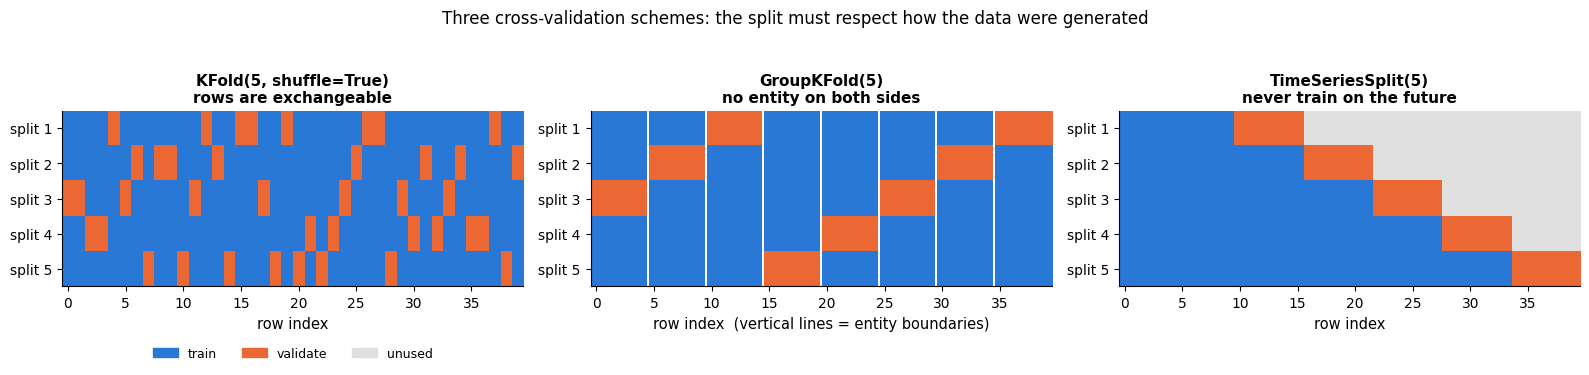

In [20]:
from matplotlib.colors import ListedColormap
from sklearn.model_selection import KFold, GroupKFold, TimeSeriesSplit

n_demo = 40
groups = np.repeat(np.arange(8), 5)               # 8 entities with 5 rows each
X_demo, y_demo = np.zeros((n_demo, 1)), np.zeros(n_demo)
schemes = [("KFold(5, shuffle=True)\nrows are exchangeable", KFold(5, shuffle=True, random_state=RANDOM_STATE), None),
           ("GroupKFold(5)\nno entity on both sides", GroupKFold(n_splits=5), groups),
           ("TimeSeriesSplit(5)\nnever train on the future", TimeSeriesSplit(n_splits=5), None)]

fig, axes = plt.subplots(1, 3, figsize=(16, 3.9))
cmap = ListedColormap(["0.88", PALETTE[0], PALETTE[1]])       # unused / train / validate
for ax, (title, splitter, g) in zip(axes, schemes):
    grid_img = np.zeros((5, n_demo))
    for s, (tr, va) in enumerate(splitter.split(X_demo, y_demo, groups=g)):
        grid_img[s, tr] = 1
        grid_img[s, va] = 2
    ax.imshow(grid_img, aspect="auto", cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
    if g is not None:                                          # show where the entities start
        for b in np.flatnonzero(np.diff(groups)) + 0.5:
            ax.axvline(b, color="white", lw=1.4)
    ax.set_yticks(range(5))
    ax.set_yticklabels([f"split {s + 1}" for s in range(5)])
    ax.set_xlabel("row index" + ("  (vertical lines = entity boundaries)" if g is not None else ""))
    ax.set_title(title, fontsize=11)
    ax.grid(False)
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=PALETTE[0]),
                        plt.Rectangle((0, 0), 1, 1, color=PALETTE[1]),
                        plt.Rectangle((0, 0), 1, 1, color="0.88")],
               labels=["train", "validate", "unused"], loc="upper center",
               bbox_to_anchor=(0.5, -0.28), ncol=3, fontsize=9)
fig.suptitle("Three cross-validation schemes: the split must respect how the data were generated", y=1.04)
plt.tight_layout()
plt.show()

Notice that `TimeSeriesSplit` trains on a growing prefix and therefore uses fewer rows in its
early splits — the price of not peeking at the future. Choosing the splitter is not a detail:
using the wrong one is the single most common way a pipeline that cross-validates beautifully
fails in production.

## 5. Baselines: what does "good" mean?

An accuracy of 0.95 sounds impressive — until you learn that 95 % of the e-mails are not
spam, and "always predict not-spam" also scores 0.95. Every experiment needs a
**baseline** that any real model must beat:

- `DummyClassifier(strategy="most_frequent")` / `strategy="stratified"` for classification;
- `DummyRegressor(strategy="mean")` / `"median"` for regression;
- a simple, well-understood model (logistic regression, a shallow tree) as a *strong
  baseline* before trying anything complex;
- for time series: "predict the last value" (notebook 16).

In [21]:
from sklearn.dummy import DummyClassifier

baselines = {}
for strategy in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    baselines[f"Dummy({strategy})"] = cross_val_score(dummy, X_trainval, y_trainval, cv=cv)
    print(f"{'DummyClassifier(' + strategy + ')':35s} CV accuracy = {baselines[f'Dummy({strategy})'].mean():.3f}")
print(f"{'kNN (k=' + str(best_k_cv) + ')':35s} CV accuracy = {cv_mean.max():.3f}")

DummyClassifier(most_frequent)      CV accuracy = 0.626
DummyClassifier(stratified)         CV accuracy = 0.503
kNN (k=9)                           CV accuracy = 0.965


A baseline is only useful if you can see how far above it the model sits, so plot the three
together. The distance from the majority-class bar to the model bar — not the height of the
model bar — is the achievement.

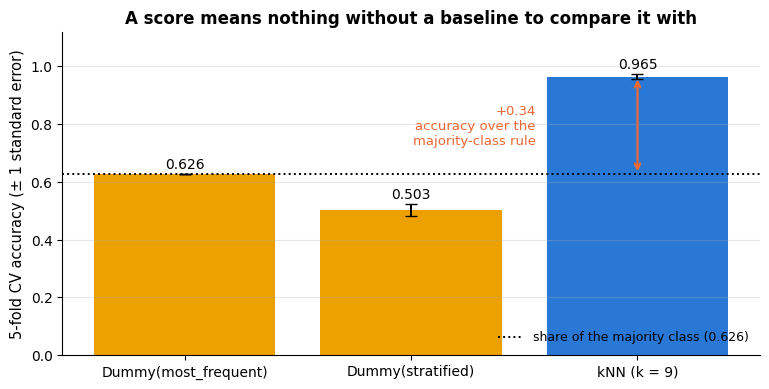

In [22]:
scores_to_plot = {**baselines, f"kNN (k = {best_k_cv})": cross_val_score(
    Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k_cv))]),
    X_trainval, y_trainval, cv=cv)}

fig, ax = plt.subplots(figsize=(9, 4.2))
names = list(scores_to_plot)
means = np.array([scores_to_plot[n].mean() for n in names])
ses = np.array([scores_to_plot[n].std(ddof=1) / np.sqrt(len(scores_to_plot[n])) for n in names])
ax.bar(names, means, yerr=ses, color=[PALETTE[3], PALETTE[3], PALETTE[0]],
       error_kw={"ecolor": "black", "capsize": 4, "lw": 1.4})
for i, m in enumerate(means):
    ax.text(i, m + ses[i] + 0.02, f"{m:.3f}", ha="center", fontsize=10)
ax.axhline(y_trainval.mean(), color="black", ls=":", lw=1.4,
           label=f"share of the majority class ({y_trainval.mean():.3f})")
ax.annotate("", xy=(2, means[2]), xytext=(2, means[0]),
            arrowprops={"arrowstyle": "<->", "lw": 1.6, "color": PALETTE[1]})
ax.text(1.55, (means[0] + means[2]) / 2, f"+{means[2] - means[0]:.2f}\naccuracy over the\nmajority-class rule",
        ha="right", va="center", fontsize=9.5, color=PALETTE[1])
ax.set_ylim(0, 1.12)
ax.set_ylabel("5-fold CV accuracy (± 1 standard error)")
ax.set_title("A score means nothing without a baseline to compare it with")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", visible=False)
plt.show()

The majority-class baseline already gets 63 %; our model's 97 % is a real improvement.
Accuracy is also not always the right metric — on imbalanced problems precision, recall,
$F_1$ and ROC-AUC tell a very different story. Notebook 7 is devoted to classification
metrics and notebook 6 to regression metrics; here we only note that `scoring=` accepts
any of them.

## 6. Learning curves: do I need more data or a better model?

A **learning curve** plots training and validation scores as a function of the *training
set size*. It is the single most useful diagnostic for the bias/variance question:

- Both curves converge to a *low* score → **high bias**: the model cannot represent the
  data; more data will not help; use a more flexible model or better features.
- A large gap between a high training score and a lower validation score that is *still
  closing* → **high variance**: more data will help, as will regularisation.
- Curves have converged with a small gap at a good score → you are done; a bigger model
  might help, more data will not.

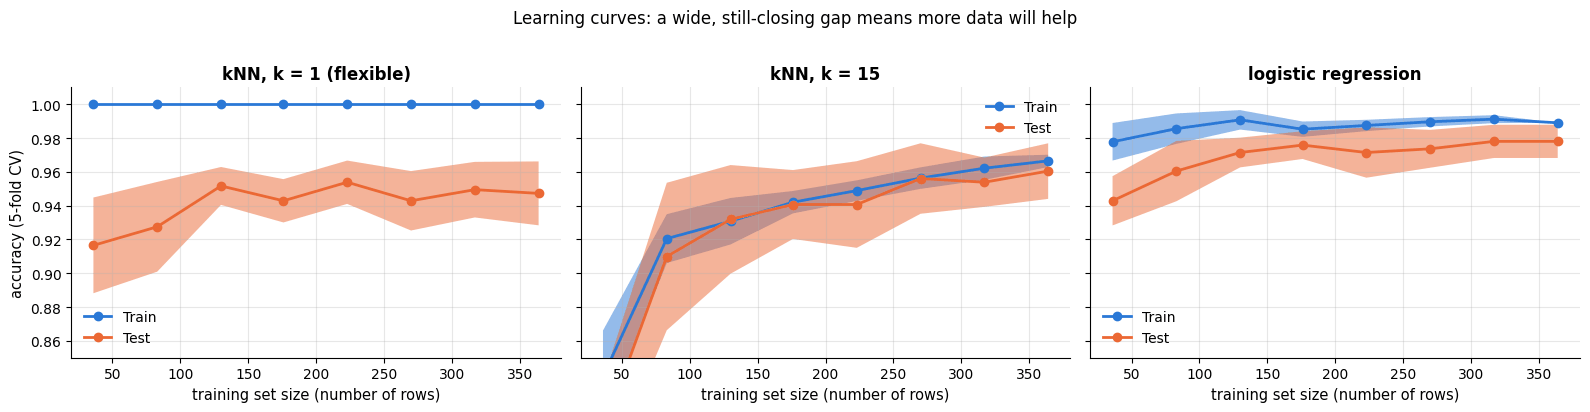

In [23]:
from sklearn.model_selection import learning_curve, LearningCurveDisplay
from sklearn.linear_model import LogisticRegression

models = {
    "kNN, k = 1 (flexible)": Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=1))]),
    "kNN, k = 15": Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=15))]),
    "logistic regression": Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))]),
}
train_sizes = np.linspace(0.1, 1.0, 8)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    LearningCurveDisplay.from_estimator(m, X_trainval, y_trainval, train_sizes=train_sizes, cv=cv,
                                        scoring="accuracy", score_type="both", ax=ax,
                                        line_kw={"marker": "o"}, std_display_style="fill_between")
    ax.set_title(name)
    ax.set_ylim(0.85, 1.01)
    ax.set_xlabel("training set size (number of rows)")
    ax.set_ylabel("")                       # one shared y-axis: no repeated label
axes[0].set_ylabel("accuracy (5-fold CV)")
fig.suptitle("Learning curves: a wide, still-closing gap means more data will help", y=1.02)
plt.tight_layout()
plt.show()

kNN with $k=1$ shows the variance signature (training score 1.0, validation score below
and rising); logistic regression converges quickly with a small gap — on this dataset a
linear model is close to the best one can do.

### 6.1 Validation curves

A **validation curve** is the complexity plot from section 2, computed by CV for one
hyper-parameter: `validation_curve` or `ValidationCurveDisplay`. Here for the regularisation
parameter `C` of logistic regression (small `C` = strong regularisation = simpler model;
notebook 7 explains the parameter).

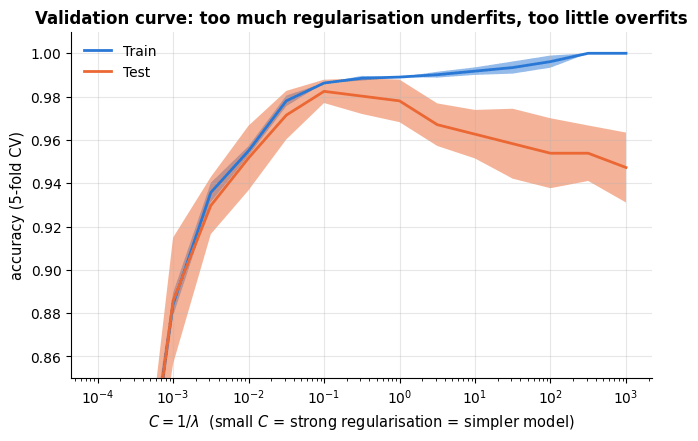

In [24]:
from sklearn.model_selection import ValidationCurveDisplay

lr = Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=2000))])
fig, ax = plt.subplots()
ValidationCurveDisplay.from_estimator(lr, X_trainval, y_trainval, param_name="lr__C",
                                      param_range=np.logspace(-4, 3, 15), cv=cv, scoring="accuracy",
                                      ax=ax, std_display_style="fill_between")
ax.set_xscale("log")
ax.set_xlabel(r"$C = 1/\lambda$  (small $C$ = strong regularisation = simpler model)")
ax.set_ylabel("accuracy (5-fold CV)")
ax.set_title("Validation curve: too much regularisation underfits, too little overfits")
ax.set_ylim(0.85, 1.01)
plt.show()

## 7. Two caveats every practitioner must know

### 7.1 Data leakage

**Leakage** is the use, at training time, of information that will not be available at
prediction time — or, more generally, any contamination of the training process by the
evaluation data (Kaufman et al., 2012). It is the most common reason for "too good to be
true" results, and Kapoor & Narayanan (2023) document it in hundreds of published papers.
Typical forms:

1. **Preprocessing on the full dataset** — fitting a scaler, an imputer, a feature
   selector or PCA on train + test before splitting. The transformation "sees" the test
   distribution. *Fix:* put every preprocessing step in a `Pipeline`, which is fitted on
   training folds only.
2. **Target leakage** — features that are consequences of the target (a "treatment
   started" flag when predicting a diagnosis; "account closed" when predicting churn).
3. **Duplicate or near-duplicate rows** across train and test (the same patient, the same
   image slightly cropped). *Fix:* `GroupKFold`.
4. **Temporal leakage** — training on the future to predict the past (notebook 16).

Let us demonstrate form 1 in a setting where it bites hard: *feature selection* on a
dataset with many pure-noise features. Selecting the features most correlated with the
target on the whole data, and *then* cross-validating, produces a phantom accuracy of
~80 % where the truth is 50 %.

In [25]:
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import RepeatedStratifiedKFold

n, d = 200, 2000
X_noise = rng.normal(size=(n, d))                 # pure noise …
y_noise = rng.integers(0, 2, n)                   # … and labels unrelated to it
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=RANDOM_STATE)

# WRONG: select the 20 "best" features using all the data, then cross-validate
selector = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)
X_selected = selector.transform(X_noise)
leaky = cross_val_score(LogisticRegression(), X_selected, y_noise, cv=rcv)

# RIGHT: selection happens inside the pipeline, i.e. inside each training fold
honest_pipe = Pipeline([("select", SelectKBest(f_classif, k=20)), ("lr", LogisticRegression())])
honest = cross_val_score(honest_pipe, X_noise, y_noise, cv=rcv)

print(f"leaky protocol   CV accuracy = {leaky.mean():.3f}   <- impossible: the data are pure noise")
print(f"honest protocol  CV accuracy = {honest.mean():.3f}   <- chance level, as it should be")

leaky protocol   CV accuracy = 0.771   <- impossible: the data are pure noise
honest protocol  CV accuracy = 0.490   <- chance level, as it should be


The two numbers are worth seeing as two *distributions*, because the point is not only that
the leaky mean is too high but that **every single one** of its 20 fold scores is far above
chance: nothing in the leaky protocol's own output would warn you. The honest protocol sits
on the chance line, exactly where a model trained on noise belongs.

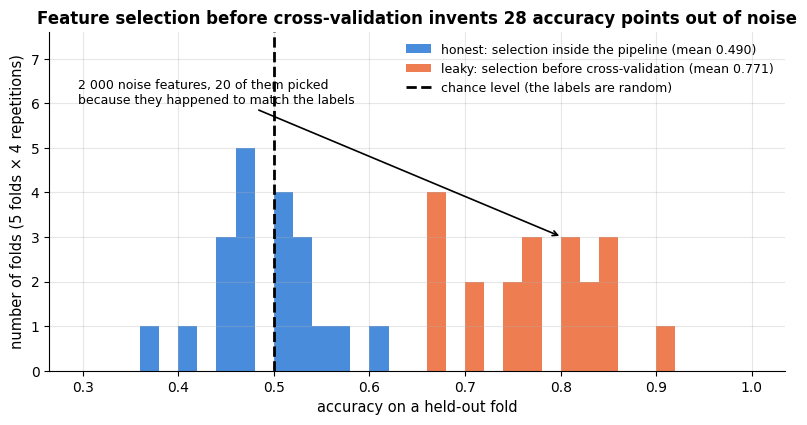

In [26]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
bins = np.linspace(0.3, 1.0, 36)
ax.hist(honest, bins=bins, color=PALETTE[0], alpha=0.85,
        label=f"honest: selection inside the pipeline (mean {honest.mean():.3f})")
ax.hist(leaky, bins=bins, color=PALETTE[1], alpha=0.85,
        label=f"leaky: selection before cross-validation (mean {leaky.mean():.3f})")
ax.axvline(0.5, color="black", ls="--", lw=2, label="chance level (the labels are random)")
ax.set_ylim(0, 7.6)
ax.annotate("2 000 noise features, 20 of them picked\nbecause they happened to match the labels",
            xy=(leaky.mean() + 0.03, 3.0), xytext=(0.295, 6.0), fontsize=9,
            arrowprops={"arrowstyle": "->", "lw": 1.2})
ax.set_xlabel("accuracy on a held-out fold")
ax.set_ylabel("number of folds (5 folds × 4 repetitions)")
ax.set_title(f"Feature selection before cross-validation invents "
             f"{100 * (leaky.mean() - honest.mean()):.0f} accuracy points out of noise")
ax.legend(loc="upper right", fontsize=9)
plt.show()

> **Warning.** *Anything* fitted to data belongs inside the cross-validated pipeline —
> scalers, imputers, encoders, feature selection, dimensionality reduction, target
> encoding, and hyper-parameter search itself. If you remember one rule from this notebook,
> make it this one.

### 7.2 No free lunch

The **no-free-lunch theorem** (Wolpert, 1996) states, loosely, that averaged over *all*
possible data-generating distributions, every learning algorithm has the same expected
performance. No algorithm is universally best; an algorithm works well on a problem
because its **inductive bias** — the assumptions built into $\mathcal{H}$ and the
learning rule (smoothness, linearity, locality, sparsity, translation invariance …) —
matches the structure of that problem. This is why we learn many algorithms in this course
and evaluate them empirically on every new dataset, why "which model is best?" has no
context-free answer, and why understanding the assumptions of each method matters more than
memorising its API. Domingos (2012) is a wonderful essay on this and eleven other lessons.

A quick illustration: a linear model and a nearest-neighbour model on two datasets whose
structure favours one or the other. The first dataset has a *linear* Bayes boundary
($y$ depends on the sign of $\mathbf{w}^\top\mathbf{x}$ plus noise), the second is the
"two moons" toy problem whose classes interleave.

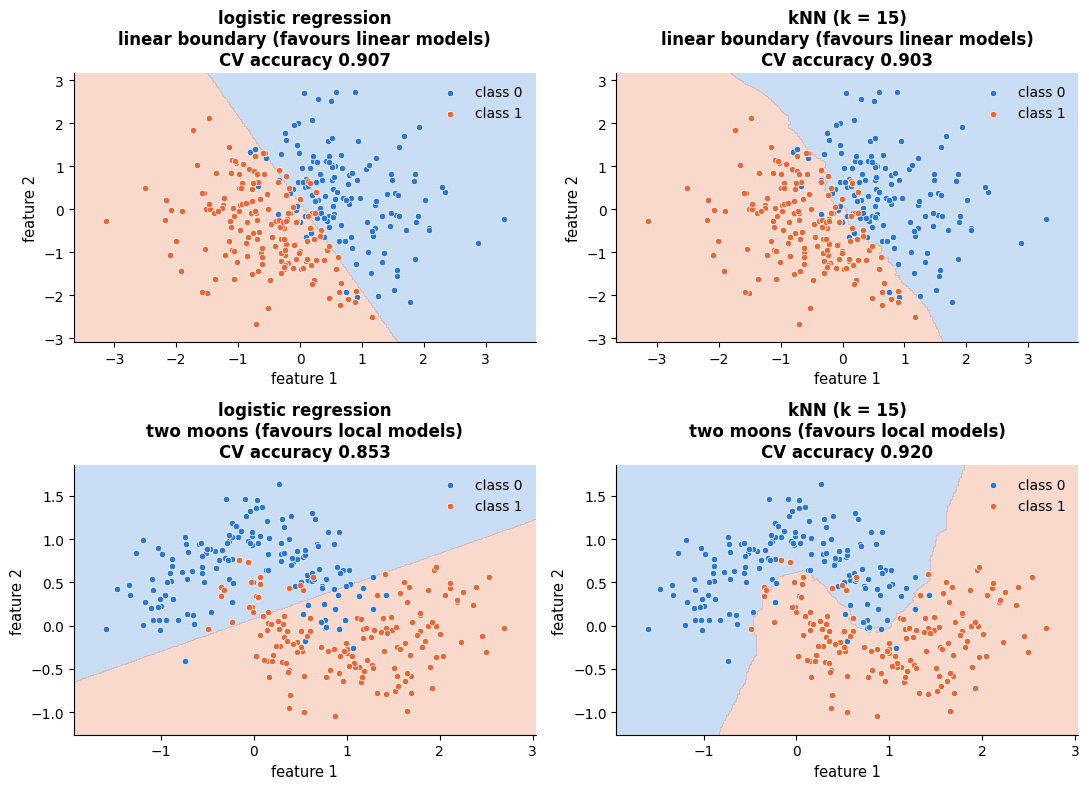

In [27]:
from sklearn.datasets import make_moons

def make_linear_data(n, d, noise=0.3, rng=rng):
    """Labels depend only on the sign of a linear function of x (plus label noise)."""
    Xl = rng.normal(size=(n, d))
    w = rng.normal(size=d)
    yl = (Xl @ w / np.linalg.norm(w) + rng.normal(0, noise, n) > 0).astype(int)
    return Xl, yl

datasets = {
    "linear boundary (favours linear models)": make_linear_data(300, 2),
    "two moons (favours local models)": make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE),
}
clfs = {"logistic regression": LogisticRegression(), "kNN (k = 15)": KNeighborsClassifier(15)}
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for i, (dname, (Xd, yd)) in enumerate(datasets.items()):
    for j, (cname, clf) in enumerate(clfs.items()):
        acc = cross_val_score(clf, Xd, yd, cv=cv).mean()
        clf.fit(Xd, yd)
        plot_decision_boundary(clf, Xd, yd, ax=axes[i, j], title=f"{cname}\n{dname}\nCV accuracy {acc:.3f}")
plt.tight_layout()
plt.show()

In two dimensions the linear problem is easy for both models. The inductive bias of the
linear model pays off when the number of features grows while the boundary stays linear:
nearest-neighbour distances become less and less informative in high dimensions (the
*curse of dimensionality*, notebook 8), whereas logistic regression only has to estimate
one direction $\mathbf{w}$.

In [28]:
print("linear boundary, n = 300 samples:")
for d in [2, 10, 30, 100]:
    Xd, yd = make_linear_data(300, d)
    acc_lr = cross_val_score(LogisticRegression(max_iter=2000), Xd, yd, cv=cv).mean()
    acc_knn = cross_val_score(KNeighborsClassifier(15), Xd, yd, cv=cv).mean()
    print(f"  d = {d:3d}   logistic regression {acc_lr:.3f}   kNN {acc_knn:.3f}")

linear boundary, n = 300 samples:
  d =   2   logistic regression 0.897   kNN 0.883
  d =  10   logistic regression 0.900   kNN 0.830
  d =  30   logistic regression 0.900   kNN 0.747
  d = 100   logistic regression 0.827   kNN 0.700


## 8. Putting it together: an evaluation recipe

Every supervised-learning project in this course follows the same skeleton; later
notebooks fill in the model-specific details.

```py
# 1. Split off a test set FIRST and never look at it until the end.
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Put ALL preprocessing into a Pipeline.
pipe = Pipeline([("prep", preprocessing), ("model", model)])

# 3. Establish baselines (Dummy*, a simple model).
# 4. Select hyper-parameters with (repeated, stratified/grouped/time-aware) cross-validation,
#    reading learning and validation curves to decide between more data / more capacity / more regularisation.
# 5. Refit the chosen configuration on train+validation, evaluate ONCE on the test set,
#    and report the metric that matches the business goal together with its uncertainty.
```

## Summary

- Supervised learning = **empirical risk minimisation** over a hypothesis space
  $\mathcal{H}$; the quantity we care about is the **risk** on unseen data, which training
  error estimates *optimistically*.
- **Underfitting** (high bias) and **overfitting** (high variance) are the two failure
  modes; the **bias–variance decomposition**
  $\text{error} = \text{bias}^2 + \text{variance} + \text{noise}$ explains the U-shaped
  test-error curve and why more data helps variance but not bias.
- Honest evaluation needs data the model has not seen: a **hold-out test set** used once,
  and **cross-validation** (stratified, grouped, or time-aware as appropriate) for model
  selection; report means *and* standard errors, apply the one-standard-error rule.
- **Learning curves** tell you whether to get more data or a better model; **validation
  curves** locate the sweet spot of a hyper-parameter.
- Always compare against **baselines**; put every data-dependent step inside a
  **pipeline** to avoid **leakage**; remember there is **no free lunch** — model choice is
  empirical and depends on the match between inductive bias and problem structure.

| Question | Tool |
|---|---|
| Honest performance estimate | held-out test set (once), `cross_val_score`, `cross_validate` |
| Choose a hyper-parameter | `ValidationCurveDisplay`, `GridSearchCV` (notebook 12) |
| More data or bigger model? | `LearningCurveDisplay` |
| Small dataset, noisy estimates | `RepeatedStratifiedKFold`, report ± standard error |
| Rows share a group / time order | `GroupKFold`, `TimeSeriesSplit` |
| Avoid leakage | `Pipeline`, `ColumnTransformer`; split before anything else |
| Is the model any good at all? | `DummyClassifier`, `DummyRegressor`, a simple strong baseline |

**Next steps:** notebook 6 (linear regression) makes the least-squares machinery behind the
polynomial fits explicit and introduces regularisation as a direct handle on the
bias–variance trade-off; notebook 7 covers classification metrics beyond accuracy;
notebook 12 returns to model selection with grid/random search and nested CV.

## Exercises

### Exercise 1 — Bayes error (easy)
In the sine example, change the noise level to `noise=0.6`. Re-run the complexity plot of
section 2. How does the optimal degree change, and where does the test-error curve now
flatten out? Explain using the bias–variance decomposition.

<details><summary>Solution sketch</summary>

The floor of the test error moves from $0.09$ to $0.36 = 0.6^2$ (the Bayes error). With
more noise, variance grows faster with degree, so the optimum shifts to a *lower* degree:
noisier data call for simpler models (or more data).
</details>

### Exercise 2 — More data (easy)
Repeat the bias–variance simulation of section 3 with `n_train=300` instead of 30. Which
of the three terms changes, and which does not?

<details><summary>Solution sketch</summary>

Variance drops by roughly a factor of 10 for every degree; bias$^2$ and noise are
unchanged. Consequently the optimal degree increases — with more data we can afford a more
flexible model.
</details>

### Exercise 3 — Leave-one-out vs. 5-fold (medium)
Using `LeaveOneOut()` and `StratifiedKFold(5)` as `cv`, estimate the accuracy of the
kNN pipeline ($k=5$) on the breast cancer training data 30 times with different random
subsamples of 150 rows. Compare the mean and the standard deviation of the two estimators
across the 30 repetitions.

<details><summary>Solution sketch</summary>

```py
from sklearn.model_selection import LeaveOneOut
loo_scores, kf_scores = [], []
for r in range(30):
    idx = rng.choice(len(X_trainval), 150, replace=False)
    Xs, ys = X_trainval.iloc[idx], y_trainval.iloc[idx]
    loo_scores.append(cross_val_score(model, Xs, ys, cv=LeaveOneOut()).mean())
    kf_scores.append(cross_val_score(model, Xs, ys, cv=StratifiedKFold(5, shuffle=True, random_state=r)).mean())
```
Both means are similar; LOO is slightly less biased (it trains on 149 rather than 120 rows)
but its standard deviation across repetitions is *not* smaller — and it costs 30× more fits.
</details>

### Exercise 4 — Leakage hunt (medium)
The following protocol has a leak. Find it, explain why it inflates the score, and fix it.

```py
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
pca = PCA(n_components=5).fit(X_scaled)
Z = pca.transform(X_scaled)
print(cross_val_score(LogisticRegression(), Z, y, cv=5).mean())
```

<details><summary>Solution sketch</summary>

Both the scaler and the PCA are fitted on all rows, including the ones that later serve as
validation folds, so the validation representation depends on validation data. On this
dataset the effect is small (PCA is unsupervised), but the protocol is wrong in principle
and can be badly wrong with supervised steps. Fix: `make_pipeline(StandardScaler(),
PCA(5), LogisticRegression())` inside `cross_val_score`.
</details>

### Exercise 5 — Learning curve for a regression problem (medium)
Load `sklearn.datasets.load_diabetes(as_frame=True)`. Plot learning curves (metric:
`neg_root_mean_squared_error`) for `LinearRegression` and for
`KNeighborsRegressor(n_neighbors=3)` inside a scaling pipeline. Which model suffers from
variance, which from bias, and would you invest in collecting more patients?

<details><summary>Solution sketch</summary>

Linear regression: the two curves meet quickly at an RMSE around 55 — bias-limited (or
noise-limited: the diabetes target is very noisy). kNN with $k=3$: a large train/validation
gap that closes slowly — variance-limited; more data would help it, but probably not
beyond the linear model. Collecting more data is unlikely to pay off; better features would.
</details>

### Exercise 6 — Nested cross-validation (hard)
Implement nested CV by hand: an outer `StratifiedKFold(5)`; inside each outer training
fold, choose $k \in \{1, 3, 5, 9, 15, 31\}$ by an inner 5-fold CV, refit, and score on the
outer validation fold. Compare the nested estimate with the (optimistic) "best inner CV
score" and with the non-nested estimate from section 4.3.

<details><summary>Solution sketch</summary>

```py
outer = StratifiedKFold(5, shuffle=True, random_state=0)
nested, inner_best = [], []
for tr, va in outer.split(X_trainval, y_trainval):
    Xtr, ytr = X_trainval.iloc[tr], y_trainval.iloc[tr]
    inner_scores = {k: cross_val_score(make_knn(k), Xtr, ytr, cv=5).mean() for k in [1, 3, 5, 9, 15, 31]}
    k_best = max(inner_scores, key=inner_scores.get)
    inner_best.append(inner_scores[k_best])
    nested.append(make_knn(k_best).fit(Xtr, ytr).score(X_trainval.iloc[va], y_trainval.iloc[va]))
```
The nested estimate is typically a little lower than the best inner score; the difference
is the selection bias. With only 6 candidate values the bias is small here; it grows with
the number of configurations tried.
</details>

## References and further reading

### Textbooks

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free at https://www.statlearning.com) — Chapters 2 and 5 cover this notebook's material at the same level, with excellent figures.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — Chapter 7 ("Model Assessment and Selection") is the definitive treatment of bias–variance, cross-validation and the bootstrap.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill. — Source of the definition of learning quoted in section 1.
- Shalev-Shwartz, S., & Ben-David, S. (2014). *Understanding Machine Learning: From Theory to Algorithms*. Cambridge University Press. (free) — Chapters 2–6 develop ERM, PAC learning and the bias–complexity trade-off rigorously.
- Vapnik, V. N. (1995). *The Nature of Statistical Learning Theory*. Springer. — The origin of statistical learning theory and structural risk minimisation.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free) — Chapter 4 on statistics and chapter 5 on decision theory complement the risk-based view.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — Chapters 1–2: a gentle practical walk through the same workflow.

### Papers

- Geman, S., Bienenstock, E., & Doursat, R. (1992). Neural networks and the bias/variance dilemma. *Neural Computation*, 4(1), 1–58. — The classic exposition of the decomposition derived in section 3.
- Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proceedings of IJCAI 1995*, 1137–1143. — Empirical comparison that established stratified 10-fold CV as the default.
- Stone, M. (1974). Cross-validatory choice and assessment of statistical predictions. *Journal of the Royal Statistical Society: Series B*, 36(2), 111–147. — The original cross-validation paper.
- Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research*, 11, 2079–2107. — Why validation scores of tuned models are optimistic.
- Varma, S., & Simon, R. (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics*, 7, 91. — Motivates nested cross-validation.
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data*, 6(4), 1–21.
- Kapoor, S., & Narayanan, A. (2023). Leakage and the reproducibility crisis in machine-learning-based science. *Patterns*, 4(9). — A taxonomy of leakage with a survey of affected fields.
- Wolpert, D. H. (1996). The lack of a priori distinctions between learning algorithms. *Neural Computation*, 8(7), 1341–1390. — The no-free-lunch theorem for supervised learning.
- Domingos, P. (2012). A few useful things to know about machine learning. *Communications of the ACM*, 55(10), 78–87. — Twelve pages of hard-won wisdom; read it now and again in a year.
- Belkin, M., Hsu, D., Ma, S., & Mandal, S. (2019). Reconciling modern machine-learning practice and the classical bias–variance trade-off. *PNAS*, 116(32), 15849–15854. — Double descent.
- Nakkiran, P., Kaplun, G., Bansal, Y., Yang, T., Barak, B., & Sutskever, I. (2020). Deep double descent: where bigger models and more data hurt. *ICLR 2020*.
- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth. — Introduces the one-standard-error rule (chapter 3).
- Pedregosa, F., et al. (2011). Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830; and Buitinck, L., et al. (2013). API design for machine learning software: experiences from the scikit-learn project. *ECML PKDD Workshop*. — The library and the design of its estimator API.
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Proceedings of SPIE 1905*, 861–870. — The breast cancer Wisconsin data.

### Documentation and online resources

- scikit-learn user guide, *Cross-validation: evaluating estimator performance* — https://scikit-learn.org/stable/modules/cross_validation.html
- scikit-learn user guide, *Validation curves: plotting scores to evaluate models* — https://scikit-learn.org/stable/modules/learning_curve.html
- scikit-learn, *Common pitfalls and recommended practices* (data leakage, randomness) — https://scikit-learn.org/stable/common_pitfalls.html
- Google, *Rules of Machine Learning* — https://developers.google.com/machine-learning/guides/rules-of-ml — Rule #1: "Don't be afraid to launch a product without machine learning"; the rest is about evaluation discipline.